# 5250 Model Validation & Comparison to 5240
## Setup

In [1]:
import importlib
import logging
import pathlib
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from use_core import constants, run_info, task

sys.path.insert(0, "..")
build_models = importlib.import_module("build-models")

sns.set()

run_info.logger.setLevel(logging.CRITICAL)

In [2]:
class MockRunConfig:
    def __init__(
        self,
        dedup_ratio: float,
        kb_transferred: int,
        num_streams: int,
        task: str,
        workload_type: str,
        io_duplex: task.TaskDuplexType,
    ) -> None:
        self.dedup_ratio = dedup_ratio
        self.kb_transferred = kb_transferred
        self.num_streams = num_streams
        self.task = task
        self.workload_type = workload_type
        self.io_duplex = io_duplex

class MockApplianceConfig:
    def __init__(
        self,
        appliance: str,
        site_version: str,
        memory: int,
        number_of_total_drives: int,
    ) -> None:
        self.appliance = appliance
        self.site_version = site_version
        self.memory = memory
        self.number_of_total_drives = number_of_total_drives

## Reading in Data

In [3]:
root_data_dir = pathlib.Path("../data")
data_dir_5240 = root_data_dir / "5240/8.2/default"
data_dir_5250 = root_data_dir / "5250/8.2/default"

In [4]:
df_5240 = build_models.get_cpu_data(data_dir_5240, "backup", "default", "5240")
df_5250 = build_models.get_cpu_data(data_dir_5250, "backup", "default", "5250")
df_vm_5240 = build_models.get_cpu_data(data_dir_5240, "backup", "vmware", "5240")
df_vm_5250 = build_models.get_cpu_data(data_dir_5250, "backup", "vmware", "5250")

## Default Workload

In [5]:
appliance_config = MockApplianceConfig("5240", constants.SoftwareVersion.VER8_2, 256 * 1024 * 1024, 4)

actual_5240 = []
predicted_5240 = []

for row in df_5240.iterrows():
    record = row[1]
    actual_5240.append(record["cpu_usage_secs"])

    run_config = MockRunConfig(record["dedup_ratio"], record["kb_transferred"], record["num_streams"], "backup", "default", task.TaskDuplexType.half)
    ri = run_info.RunInfo(run_config, appliance_config)
    predicted_5240.append(ri.cpu_usage())



appliance_config = MockApplianceConfig("5250", constants.SoftwareVersion.VER8_2, 256 * 1024 * 1024, 4)

actual_5250 = []
predicted_5250 = []

for row in df_5250.iterrows():
    record = row[1]
    actual_5250.append(record["cpu_usage_secs"])

    run_config = MockRunConfig(record["dedup_ratio"], record["kb_transferred"], record["num_streams"], "backup", "default", task.TaskDuplexType.half)
    ri = run_info.RunInfo(run_config, appliance_config)
    predicted_5250.append(ri.cpu_usage())

df_5250["predicted"] = predicted_5250
df_5250["diff"] = df_5250["predicted"] - df_5250["cpu_usage_secs"]

In [6]:
df_5250[["dedup_ratio", "num_streams", "kb_transferred", "swapout", "cpu_usage_secs", "diff"]]

,dedup_ratio,num_streams,kb_transferred,swapout,cpu_usage_secs,diff
0,0.00,1,30735,0,4.291765,6.708235
1,0.00,2,61470,0,9.058824,11.941176
2,0.00,6,184410,0,31.441739,29.558261
3,0.00,12,368820,0,78.412500,42.587500
4,0.00,24,737640,0,170.606667,70.393333
5,0.00,48,1475281,0,381.858750,100.141250
6,0.00,72,2212922,0,625.832229,96.167771
7,0.00,96,2950563,0,860.807359,102.192641
8,0.00,120,3688203,4569,1042.642676,161.357324
9,0.50,1,30735,0,3.790769,4.209231


In [13]:
ri.cpu_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:         cpu_usage_secs   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                          1.071e+04
Date:                Thu, 01 Oct 2020   Prob (F-statistic):                    5.35e-69
Time:                        16:08:15   Log-Likelihood:                         -295.06
No. Observations:                  52   AIC:                                      596.1
Df Residuals:                      49   BIC:                                      602.0
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
kb_transferred                 0.0003   4.04e-06     80.798      0.000       0.000       0.000
kb_transferred:dedup_ratio    -0.0002    4.1e-06    -40.906      0.000      -0.000      -0.000
swapout                       -0.0020      0.002     -0.977      0.333      -0.006       0.002
==============================================================================
Omnibus:                       17.068   Durbin-Watson:                   0.523
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.959
Skew:                           1.012   Prob(JB):                     8.49e-07
Kurtosis:                       5.968   Cond. No.                     1.78e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 1.78e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

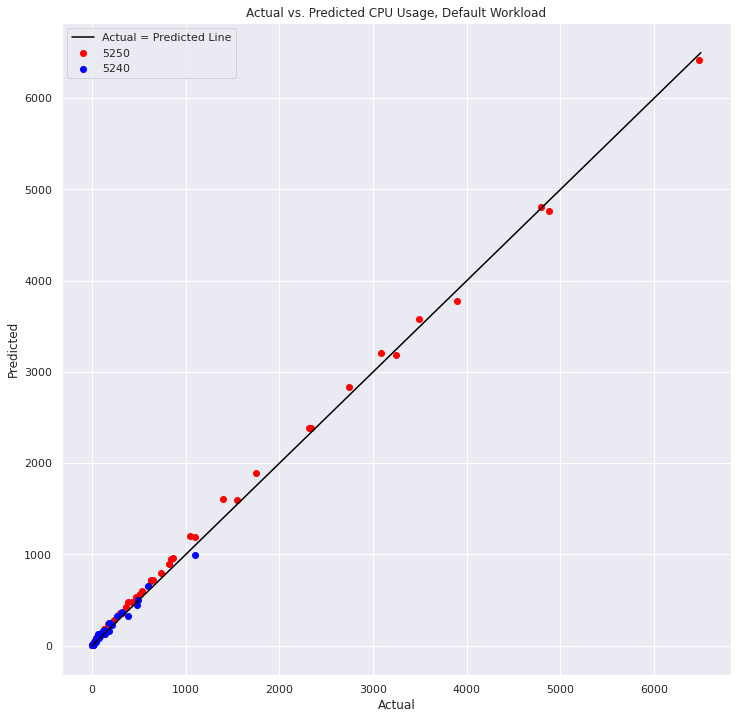

In [14]:
_, ax = plt.subplots(figsize=(12, 12))
ax.plot([0, 6500], [0, 6500], color="black", label="Actual = Predicted Line")

ax.scatter(actual_5250, predicted_5250, color="red", label="5250")
ax.scatter(actual_5240, predicted_5240, color="blue", label="5240")

ax.legend()
ax.set(title="Actual vs. Predicted CPU Usage, Default Workload", xlabel="Actual", ylabel="Predicted");

## VMWare Workload

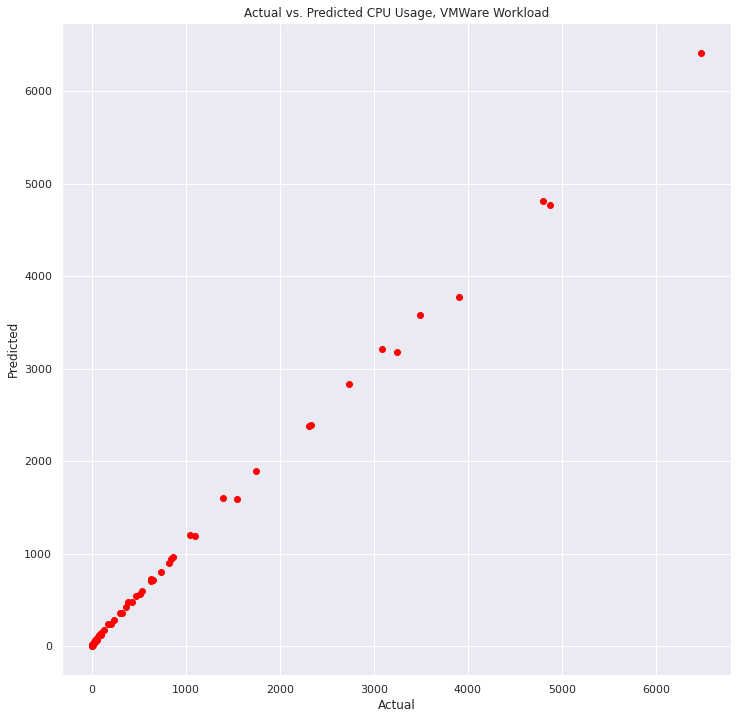

In [9]:
appliance_config = MockApplianceConfig("5250", constants.SoftwareVersion.VER8_2, 256 * 1024 * 1024, 4)

actual = []
predicted = []

for row in df_vm_5250.iterrows():
    record = row[1]
    actual.append(record["cpu_usage_secs"])

    run_config = MockRunConfig(record["dedup_ratio"], record["kb_transferred"], record["num_streams"], "backup", "vmware", task.TaskDuplexType.half)
    ri = run_info.RunInfo(run_config, appliance_config)
    predicted.append(ri.cpu_usage())

_, ax = plt.subplots(figsize=(12, 12))
ax.scatter(actual, predicted, color="red")
ax.set(title="Actual vs. Predicted CPU Usage, VMWare Workload", xlabel="Actual", ylabel="Predicted");

## Comparison

In [11]:
appliance_config_5240 = MockApplianceConfig("5240", constants.SoftwareVersion.VER8_2, 256 * 1024 * 1024, 4)

appliance_config_5250 = MockApplianceConfig("5250", constants.SoftwareVersion.VER8_2, 256 * 1024 * 1024, 4)

vals_5240 = []
vals_5250 = []

for row in df_5240.iterrows():
    record = row[1]
    vals_5240.append(record["cpu_usage_secs"])

    run_config = MockRunConfig(record["dedup_ratio"], record["kb_transferred"], record["num_streams"], "backup", "default", io_duplex=task.TaskDuplexType.half)
    ri = run_info.RunInfo(run_config, appliance_config)
    vals_5250.append(ri.cpu_usage())

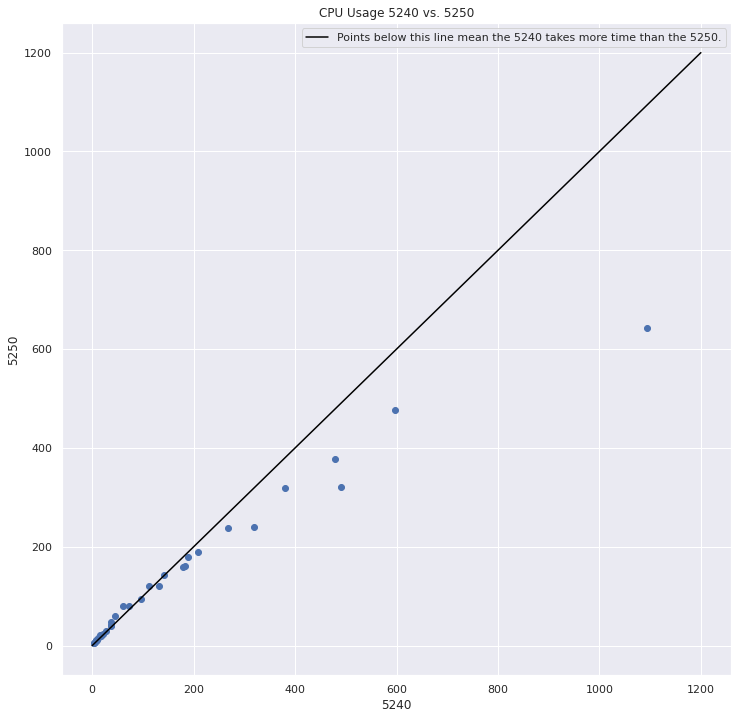

In [12]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.scatter(vals_5240, vals_5250)
ax.plot([0, 1200], [0, 1200], color="black", label="Points below this line mean the 5240 takes more time than the 5250.")
ax.legend()
ax.set(title="CPU Usage 5240 vs. 5250", xlabel="5240", ylabel="5250");